<h4 style='text-align: center;''>💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢💢</h4>

<h1 style='text-align: center; font-family: Colonna MT; font-size: 25px; font-weight: 600'>IRIS FLOWER MACHINE LEARNING CLASSIFICATION <br>
<span style="text-align:center; font-family:Arial, sans-serif; font-size:16px; color:#555;">
    <strong>Chausiku Kassimu</strong>
    | data Scientist | Machine Learning Enthusiast | Python Developer<br>
    📧 <a href="mailto:chausikukassimu1@gmail.com">chausikukassimu1@gmail.com</a> | 💢 
</span>
</h1>

----

In [219]:
    # ── Data Manipulation and Visualizations Libraries
    from typing import List, Union, Optional
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np
    import warnings

    # ── Scientific Computiong and Statistics Libraries
    from scipy.stats import norm, jarque_bera
    from scipy.stats import skew, kurtosis
    from scipy.stats import pearsonr
    from scipy import stats
    
    # ── Machine Learning Models from Scikit Learn
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.naive_bayes import GaussianNB
    from sklearn.svm import SVC
    from sklearn.ensemble import (
        RandomForestClassifier,
        GradientBoostingClassifier,
        ExtraTreesClassifier
        )

     # ── Features Preprocessing and Model Evaluations
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.preprocessing import LabelEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import Pipeline


    from sklearn.preprocessing import label_binarize
    from sklearn.model_selection import cross_val_score
    from sklearn.metrics import (
        classification_report,
        confusion_matrix,
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_curve, 
        auc
        )

    print("\n[1/7] Libraries Imported Successfully\n")


[1/7] Libraries Imported Successfully



In [220]:
df      = sns.load_dataset("iris")
X       = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
le      = LabelEncoder()
y       = le.fit_transform(df["species"])

print("\n[1/7] Features and Targert Defined Successfully\n")


[1/7] Features and Targert Defined Successfully



In [221]:
def _statistics(df: pd.DataFrame, variables: Optional[List[str]] = None, group: Optional[str] = None) -> pd.DataFrame:
    grouped  = df.groupby(group) if group else [(None, df)]
    results  = []
    
    for variable in variables:
        for name, df in grouped:
            counts        =  df[variable].count()
            mean_val      =  df[variable].mean()
            median_val    =  df[variable].median()
            mode_val      =  df[variable].mode().iloc[0] if not df[variable].mode().empty else np.nan
            std_dev       =  df[variable].std()
            variance      =  df[variable].var()
            value_range   =  df[variable].max() - df[variable].min()
            iqr           =  df[variable].quantile(0.75) - df[variable].quantile(0.25)
            
            skewness_val  =  skew(df[variable], nan_policy='omit')
            kurtosis_val  =  kurtosis(df[variable], nan_policy='omit')
            jb_stat, jb_p =  jarque_bera(df[variable])
            jb_p_interp   =  'Non-Normal' if jb_p < 0.05 else 'Normal'
            jb_p_fmt      =  f'<0.05' if jb_p < 0.05 else f'{jb_p:.3f}'
    
            results.append({
                'Variables':       variable,
                group if group else 'None': name,
                'Counts':       counts,
                'Mean':         mean_val,
                'Median':       median_val,
                'Mode':         mode_val,
                'Std':          std_dev,
                'Variance':     variance,
                'Range':        value_range,
                'IQR':          iqr,
                'Skewness':     skewness_val,
                'Kurtosis':     kurtosis_val,
                'JB p-value':   jb_p_fmt,
                'JB Notes':     jb_p_interp,
            })
    results = pd.DataFrame(results)
    results = results.drop(columns=['None']) if group is None else results
    return results

variables = df.select_dtypes(include=[np.number]).columns
results    = _statistics(df, variables, group="species")
display(results)

,Variables,species,Counts,Mean,Median,Mode,Std,Variance,Range,IQR,Skewness,Kurtosis,JB p-value,JB Notes
0,sepal_length,setosa,50,5.01,5.00,5.00,0.35,0.12,1.50,0.40,0.12,-0.35,0.834,Normal
1,sepal_length,versicolor,50,5.94,5.90,5.50,0.52,0.27,2.10,0.70,0.10,-0.60,0.659,Normal
2,sepal_length,virginica,50,6.59,6.50,6.30,0.64,0.40,3.00,0.68,0.11,-0.09,0.939,Normal
3,sepal_width,setosa,50,3.43,3.40,3.40,0.38,0.14,2.10,0.48,0.04,0.74,0.558,Normal
4,sepal_width,versicolor,50,2.77,2.80,3.00,0.31,0.10,1.40,0.48,-0.35,-0.45,0.484,Normal
5,sepal_width,virginica,50,2.97,3.00,3.00,0.32,0.10,1.60,0.38,0.35,0.52,0.447,Normal
6,petal_length,setosa,50,1.46,1.50,1.40,0.17,0.03,0.90,0.18,0.10,0.80,0.487,Normal
7,petal_length,versicolor,50,4.26,4.35,4.50,0.47,0.22,2.10,0.60,-0.59,-0.07,0.235,Normal
8,petal_length,virginica,50,5.55,5.55,5.10,0.55,0.30,2.40,0.78,0.53,-0.26,0.286,Normal
9,petal_width,setosa,50,0.25,0.20,0.20,0.11,0.01,0.50,0.10,1.22,1.43,<0.05,Non-Normal


In [222]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
    )

print("\n[2/7] Test and Training Features Splitted Successfully \n")


[2/7] Test and Training Features Splitted Successfully 



In [204]:
def preprocessor_pipeline(X_train: pd.DataFrame):
    num_cols      = X_train.select_dtypes(include=["int64", "float64"]).columns
    cat_cols      = X_train.select_dtypes(include=["object", "category", "bool"]).columns
    num_pipeline  = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    cat_pipeline  = Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    ))
                    ])
    
    preprocessor = ColumnTransformer([
                    ("num", num_pipeline, num_cols),
                    ("cat", cat_pipeline, cat_cols)
                    ])
    
    return preprocessor

print("\n[3/7] Features Preprocessing Pipeline Created Successfully \n")


[3/7] Features Preprocessing Pipeline Created Successfully 



In [205]:
preprocessor = preprocessor_pipeline(X_train)
display(preprocessor)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [209]:
def train_models(X_train, y_train, X_test, y_test, models):
    results            = []
    trained_models     = {}

    for name, model in models.items():
        preprocessor = preprocessor_pipeline(X_train)
        pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)

        score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
        auc = roc_auc_score(y_test, y_prob, multi_class="ovr",  average="macro")
        
        results.append({
            "Model":         name,
            "Accuracy":      accuracy_score(y_test, y_pred),
            "Precision":     precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "Recall":        recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "F1 Score":      f1_score(y_test, y_pred, average="weighted", zero_division=0),
            "CV Mean":       score.mean(),
            "CV Std":        score.std(),
            "AUC":           auc,
            
            })

        trained_models[name] = pipeline

    report = (pd.DataFrame(results).sort_values(by="Accuracy",ascending=False).reset_index(drop=True) )
    return trained_models, report

In [210]:
models = {
    "Logistic Regression":     LogisticRegression(max_iter=1000),
    "Decision Tree":           DecisionTreeClassifier(random_state=42),
    "Random Forest":           RandomForestClassifier(random_state=42),
    "Extra Trees":             ExtraTreesClassifier(random_state=42),
    "Gradient Boosting":       GradientBoostingClassifier(random_state=42),
    "KNN":                     KNeighborsClassifier(),
    "SVM":                     SVC(probability=True,random_state=42),
    "Naive Bayes":             GaussianNB()
    }

trained_models, report = train_models(X_train, y_train, X_test, y_test, models)
print("\n[4/7] Models Trained Successfully  \n")


[4/7] Models Trained Successfully  



In [211]:
display(report)

,Model,Accuracy,Precision,Recall,F1 Score,CV Mean,CV Std,AUC
0,SVM,0.97,0.97,0.97,0.97,0.97,0.03,1.00
1,Naive Bayes,0.97,0.97,0.97,0.97,0.96,0.03,0.99
2,Gradient Boosting,0.97,0.97,0.97,0.97,0.97,0.02,1.00
3,Logistic Regression,0.93,0.93,0.93,0.93,0.96,0.03,1.00
4,Decision Tree,0.93,0.93,0.93,0.93,0.94,0.02,0.95
5,Extra Trees,0.93,0.93,0.93,0.93,0.96,0.03,1.00
6,KNN,0.93,0.94,0.93,0.93,0.97,0.03,0.99
7,Random Forest,0.90,0.90,0.90,0.90,0.95,0.02,0.99


In [223]:
best_model_name      = report.iloc[0]["Model"]
model                = trained_models[best_model_name]
display(model)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [224]:
prediction           = model.predict(X_test)

print("\n[5/7] The Best Model:", best_model_name, "Accuracy:",  round(report.iloc[0]["Accuracy"], 2))
print("[5/7] The Best Model Predictions:",  le.inverse_transform(prediction))


[5/7] The Best Model: SVM Accuracy: 0.97
[5/7] The Best Model Predictions: ['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


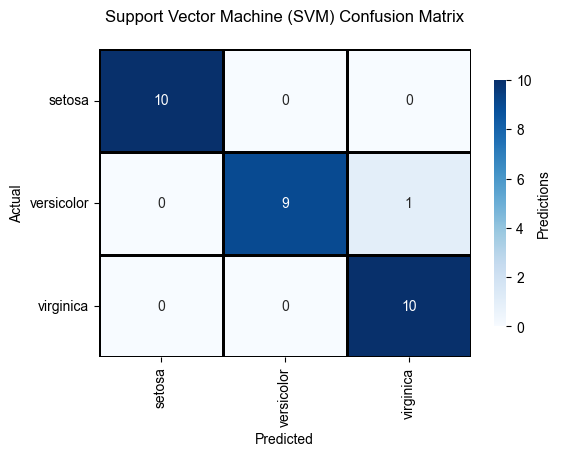

In [228]:
    plt.figure(figsize=(6,4))
    sns.heatmap(
        confusion_matrix(y_test, prediction),
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidth=0.8,
        linecolor="black",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        cbar_kws={"label": "Predictions", "shrink": 0.8}
    )
    
    plt.title("Support Vector Machine (SVM) Confusion Matrix", pad=20)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

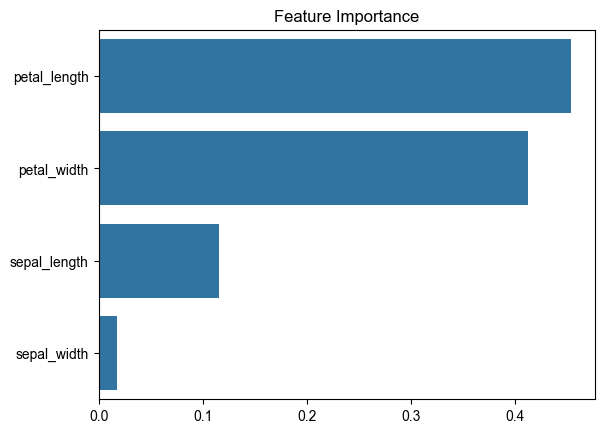

In [226]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

importance   = pd.DataFrame({"Feature": X.columns, "Importance": rf_model.feature_importances_})
importance   = importance.sort_values(by="Importance", ascending=False)
sns.barplot(data=importance, x="Importance", y="Feature")

plt.title("Feature Importance")
plt.xlabel("")
plt.ylabel("")
plt.show()

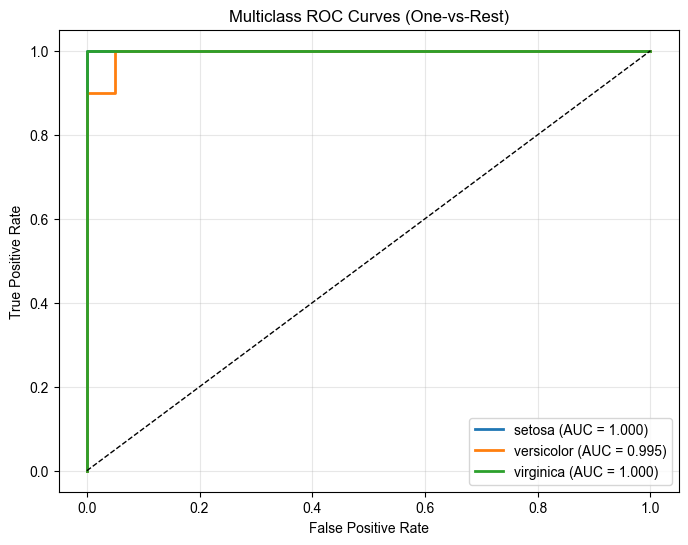

In [227]:
y_score = model.decision_function(X_test)
classes = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{le.classes_[i]} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [218]:
new_flower          =  df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
prediction          =  model.predict(new_flower)
df['Prediction']    =  le.inverse_transform(prediction)
display(df.head(15))

,sepal_length,sepal_width,petal_length,petal_width,species,Prediction
0,5.10,3.50,1.40,0.20,setosa,setosa
1,4.90,3.00,1.40,0.20,setosa,setosa
2,4.70,3.20,1.30,0.20,setosa,setosa
3,4.60,3.10,1.50,0.20,setosa,setosa
4,5.00,3.60,1.40,0.20,setosa,setosa
5,5.40,3.90,1.70,0.40,setosa,setosa
6,4.60,3.40,1.40,0.30,setosa,setosa
7,5.00,3.40,1.50,0.20,setosa,setosa
8,4.40,2.90,1.40,0.20,setosa,setosa
9,4.90,3.10,1.50,0.10,setosa,setosa



<div style="background-color: gray; padding-top: 20;">
<h1 style='text-align: center; font-family: Colonna MT; font-size: 30px; font-weight: 600'><br>Data to Drive Meaningful Insights and Solutions<br>
    <span style="text-align:center; font-family:Arial, sans-serif; font-size:16px; color:#555;">
        <strong>Chausiku Kassimu</strong> |
        Data Analyst | Machine Learning Enthusiast | Python Developer<br>
        📧 <a href="mailto:chausikukassimu1@gmail.com">chausikukassimu1@gmail.com</a>
    </span>
    <br>
    </h1>
    </div>